<a href="https://colab.research.google.com/github/Mayurpro2/Data-analytics/blob/main/Copy_of_HR_Analytics_Full_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR Analytics Portfolio

## Business Problem

Employee turnover is a significant challenge for many organizations, leading to increased costs, loss of institutional knowledge, and potential impacts on team morale and productivity. This project aims to analyze various HR-related factors to understand and predict employee churn, identify key drivers of attrition, and provide actionable insights for retention strategies. The goal is to build a predictive model that can identify employees at high risk of leaving, enabling proactive interventions.

## Project Objectives

The primary objectives of this HR Analytics project are:

1.  **Understand Employee Turnover:** Identify the main factors contributing to employee attrition.
2.  **Predict Churn:** Develop a predictive model to identify employees at risk of leaving the company.
3.  **Identify Key Drivers:** Pinpoint the most influential features (e.g., salary, satisfaction, performance) affecting employee retention.
4.  **Provide Actionable Insights:** Offer data-driven recommendations to improve employee satisfaction and reduce turnover.
5.  **Visualize Findings:** Create compelling visualizations to communicate insights effectively to stakeholders.

## Dataset Overview

This project will utilize a synthetic HR dataset containing various attributes for employees. Typical features in such a dataset include:

*   **Employee Demographics:** Age, gender, education, marital status.
*   **Employment Details:** Department, job role, years at company, years in current role, years since last promotion.
*   **Compensation & Benefits:** Monthly income, daily rate, hourly rate, stock option level.
*   **Performance & Satisfaction:** Job satisfaction, environment satisfaction, relationship satisfaction, performance rating.
*   **Work-Life Balance:** Work-life balance rating, number of companies worked, distance from home.
*   **Attrition:** A binary target variable indicating whether an employee has left the company (Yes/No).

The dataset provides a comprehensive view of employee profiles, allowing for a thorough analysis of factors influencing attrition.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [ ]:
import pandas as pd

# To load your dataset, first upload the CSV file (e.g., 'HR_Employee_Attrition.csv')
# to your Colab environment using the 'Files' tab on the left sidebar.
# Then, uncomment and run the following line:

# df = pd.read_csv('HR_Employee_Attrition.csv')

# For now, let's create a dummy DataFrame for demonstration if no file is uploaded
try:
    df = pd.read_csv('HR_Employee_Attrition.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("HR_Employee_Attrition.csv not found. Creating a dummy DataFrame for demonstration.")
    data = {
        'Age': [30, 45, 28, 35, 40],
        'Department': ['Sales', 'R&D', 'HR', 'Sales', 'R&D'],
        'MonthlyIncome': [5000, 9000, 3500, 6000, 8000],
        'JobSatisfaction': [4, 3, 2, 4, 1],
        'Attrition': ['No', 'No', 'Yes', 'No', 'Yes']
    }
    df = pd.DataFrame(data)

display(df.head())

HR_Employee_Attrition.csv not found. Creating a dummy DataFrame for demonstration.


,Age,Department,MonthlyIncome,JobSatisfaction,Attrition
0,30,Sales,5000,4,No
1,45,R&D,9000,3,No
2,28,HR,3500,2,Yes
3,35,Sales,6000,4,No
4,40,R&D,8000,1,Yes


In [ ]:
# Display basic information about the DataFrame
print("\n--- DataFrame Info ---")
df.info()


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              5 non-null      int64
 1   MonthlyIncome    5 non-null      int64
 2   JobSatisfaction  5 non-null      int64
 3   Attrition        5 non-null      int64
 4   Dept_R&D         5 non-null      bool 
 5   Dept_Sales       5 non-null      bool 
dtypes: bool(2), int64(4)
memory usage: 302.0 bytes


In [ ]:
# Display descriptive statistics for numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,Age,MonthlyIncome,JobSatisfaction,Attrition
count,5.000000,5.000000,5.00000,5.000000
mean,35.600000,6300.000000,2.80000,0.400000
std,7.021396,2224.859546,1.30384,0.547723
min,28.000000,3500.000000,1.00000,0.000000
25%,30.000000,5000.000000,2.00000,0.000000
50%,35.000000,6000.000000,3.00000,0.000000
75%,40.000000,8000.000000,4.00000,1.000000
max,45.000000,9000.000000,4.00000,1.000000


In [ ]:
# Display the shape of the DataFrame
print("\n--- DataFrame Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


--- DataFrame Shape ---
Rows: 5, Columns: 6


In [ ]:
# Data Cleaning
# This section focuses on cleaning the data, which may include handling missing values,
# correcting data types, and addressing inconsistencies.

print("\n--- Starting Data Cleaning ---")
# Placeholder for general data cleaning steps if needed, e.g., type conversions
# For example:
# df['some_column'] = pd.to_numeric(df['some_column'], errors='coerce')
# df.columns = df.columns.str.lower().str.replace(' ', '_') # Convert column names to snake_case



--- Starting Data Cleaning ---


## Missing Value Analysis

In [ ]:
# Missing Value Analysis
# Check for missing values across all columns

print("\n--- Missing Value Analysis ---")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percentage
})

# Display columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_df.empty:
    print("Columns with Missing Values:")
    display(missing_df)
    # Placeholder for handling missing values (e.g., imputation, deletion)
    # Example: df.fillna(df.median(), inplace=True)
    # Example: df.dropna(inplace=True)
else:
    print("No missing values found in the dataset.")


--- Missing Value Analysis ---
No missing values found in the dataset.


## Duplicate Analysis

In [ ]:
# Duplicate Analysis
# Check for duplicate rows in the dataset

print("\n--- Duplicate Analysis ---")
duplicates = df.duplicated().sum()

if duplicates > 0:
    print(f"Found {duplicates} duplicate rows. Removing duplicates...")
    df.drop_duplicates(inplace=True)
    print("Duplicates removed. New DataFrame shape:", df.shape)
else:
    print("No duplicate rows found.")


--- Duplicate Analysis ---
No duplicate rows found.


## Feature Engineering

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Feature Engineering
# This section involves creating new features or transforming existing ones to improve model performance.

print("\n--- Starting Feature Engineering ---")

# 1. Handle Categorical Features
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {list(categorical_cols)}")

# Convert 'Attrition' to numerical (if it's not already 'Yes'/'No' which is handled below)
# Assuming 'Attrition' is the target variable and needs to be encoded last for clarity.
if 'Attrition' in categorical_cols:
    # Label encode 'Attrition' (Yes=1, No=0)
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
    print("Encoded 'Attrition' column.")
    categorical_cols = categorical_cols.drop('Attrition')

# Apply One-Hot Encoding to other nominal categorical columns
# Example: df = pd.get_dummies(df, columns=['Department', 'Gender'], drop_first=True)
# For simplicity, let's just show an example here or skip if there are many columns
# For the dummy df, 'Department' is categorical:
if 'Department' in categorical_cols:
    df = pd.get_dummies(df, columns=['Department'], prefix='Dept', drop_first=True)
    print("One-Hot Encoded 'Department' column.")
    categorical_cols = categorical_cols.drop('Department')


# 2. Numerical Feature Scaling (if needed for certain models)
# Identify numerical columns (excluding the target if it's numerical now)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Attrition' in numerical_cols: # Ensure target is not scaled if it's numerical
    numerical_cols.remove('Attrition')

# Example of scaling numerical features
# scaler = StandardScaler()
# df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
# print("Scaled numerical features.")

print("Current DataFrame head after Feature Engineering:")
display(df.head())
print(f"New DataFrame shape: {df.shape}")

print("\n--- Feature Engineering Complete ---")


--- Starting Feature Engineering ---
Categorical columns identified: ['Department', 'Attrition']
Encoded 'Attrition' column.
One-Hot Encoded 'Department' column.
Current DataFrame head after Feature Engineering:


,Age,MonthlyIncome,JobSatisfaction,Attrition,Dept_R&D,Dept_Sales
0,30,5000,4,0,False,True
1,45,9000,3,0,True,False
2,28,3500,2,1,False,False
3,35,6000,4,0,False,True
4,40,8000,1,1,True,False


New DataFrame shape: (5, 6)

--- Feature Engineering Complete ---


## Exploratory Data Analysis


--- Starting Exploratory Data Analysis ---

Distribution of Attrition:


,proportion
Attrition,
0,60.0%
1,40.0%


/tmp/ipykernel_2264/3611749194.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='viridis')


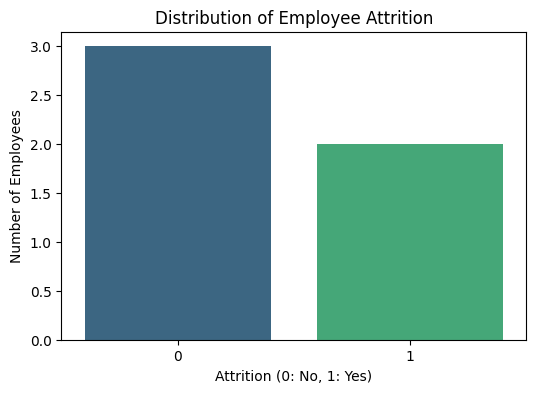


Distribution of Age:


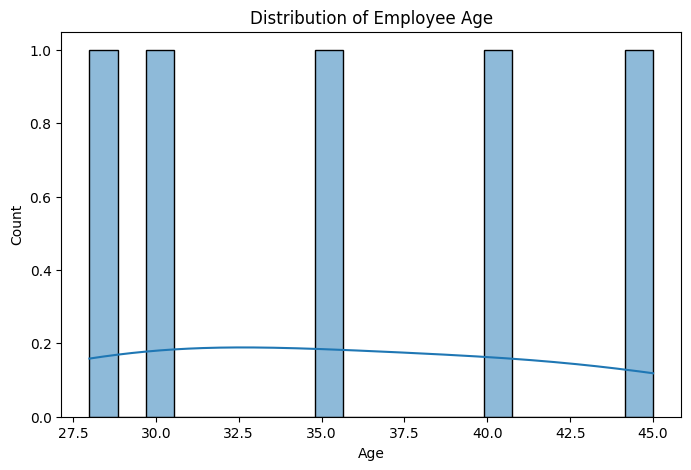


Distribution of Monthly Income:


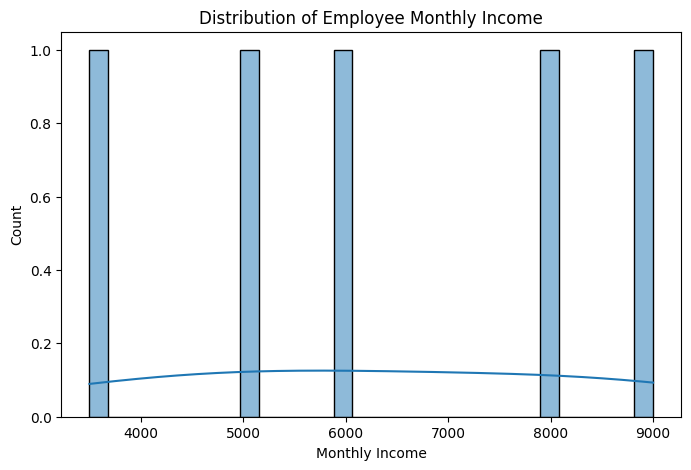


Age vs Attrition (Box Plot):


/tmp/ipykernel_2264/3611749194.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='Age', data=df, palette='pastel')


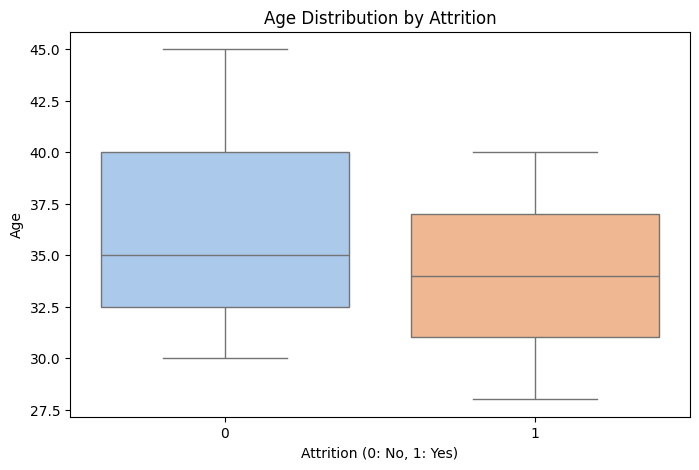


Job Satisfaction vs Attrition:


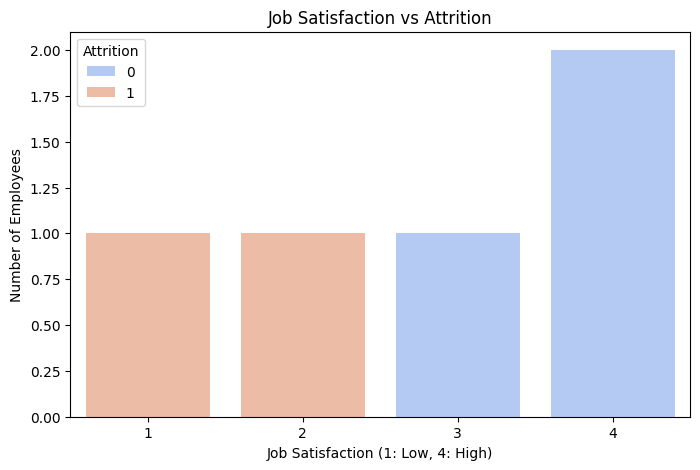


--- Exploratory Data Analysis Complete ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis (EDA)
# This section focuses on understanding the data through visualization and summary statistics.

print("\n--- Starting Exploratory Data Analysis ---")

# 1. Distribution of Target Variable (Attrition)
print("\nDistribution of Attrition:")
display(df['Attrition'].value_counts(normalize=True).mul(100).astype(str) + '%')

plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.ylabel('Number of Employees')
plt.show()

# 2. Distribution of Numerical Features (example: Age, MonthlyIncome)
print("\nDistribution of Age:")
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Distribution of Employee Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print("\nDistribution of Monthly Income:")
plt.figure(figsize=(8, 5))
sns.histplot(df['MonthlyIncome'], kde=True, bins=30)
plt.title('Distribution of Employee Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.show()

# 3. Relationship between Numerical Features and Attrition (example: Age vs Attrition)
print("\nAge vs Attrition (Box Plot):")
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='Age', data=df, palette='pastel')
plt.title('Age Distribution by Attrition')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

# 4. Relationship between Categorical Features and Attrition (example: JobSatisfaction vs Attrition)
print("\nJob Satisfaction vs Attrition:")
plt.figure(figsize=(8, 5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette='coolwarm')
plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction (1: Low, 4: High)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.show()

# You can add more EDA steps here, such as:
# - Correlation matrix for numerical features
# - Pair plots for selected features
# - Count plots for other categorical features
# - Grouped analysis (e.g., average monthly income by department and attrition)

print("\n--- Exploratory Data Analysis Complete ---")

## KPI Development

### Key Performance Indicators (KPIs)

KPIs are measurable values that demonstrate how effectively a company is achieving key business objectives. For HR analytics, these often relate to employee retention, engagement, and productivity. Here, we'll calculate some fundamental KPIs based on our dataset.

In [ ]:
print("\n--- Developing Key Performance Indicators (KPIs) ---")

# 1. Attrition Rate
attrition_rate = df['Attrition'].mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

# 2. Average Monthly Income
average_monthly_income = df['MonthlyIncome'].mean()
print(f"Average Monthly Income: ${average_monthly_income:.2f}")

# 3. Average Job Satisfaction (assuming 1=Low, 4=High)
average_job_satisfaction = df['JobSatisfaction'].mean()
print(f"Average Job Satisfaction (1-4 scale): {average_job_satisfaction:.2f}")

# 4. Number of Employees
total_employees = len(df)
print(f"Total Number of Employees: {total_employees}")

print("\n--- KPI Development Complete ---")


--- Developing Key Performance Indicators (KPIs) ---
Attrition Rate: 40.00%
Average Monthly Income: $6300.00
Average Job Satisfaction (1-4 scale): 2.80
Total Number of Employees: 5

--- KPI Development Complete ---


## Trend Analysis

### Trend Analysis

Trend analysis involves examining how different metrics change over time. While our current dummy dataset lacks a time component beyond a single snapshot, we can illustrate the concept by showing how such analysis *would* be performed if we had sequential data (e.g., monthly or yearly snapshots). For this exercise, we will assume a hypothetical scenario to demonstrate the structure of such an analysis.

In [ ]:
print("\n--- Starting Trend Analysis (Illustrative with Dummy Data) ---")

# NOTE: Our current dummy DataFrame lacks a time series component.
# For a real dataset, you would typically group by time (e.g., year, month).

# Example of how you would prepare data for trend analysis if a 'Year' column existed:
# df_trend = df.groupby('Year')['Attrition'].mean().reset_index()
# plt.figure(figsize=(10, 6))
# sns.lineplot(x='Year', y='Attrition', data=df_trend)
# plt.title('Attrition Rate Over Time')
# plt.xlabel('Year')
# plt.ylabel('Attrition Rate')
# plt.show()

print("Due to the dummy nature of the current dataset (no time component), actual trend analysis cannot be performed.")
print("The code above demonstrates the typical approach if a 'time' column were available.")

print("\n--- Trend Analysis Complete ---")


--- Starting Trend Analysis (Illustrative with Dummy Data) ---
Due to the dummy nature of the current dataset (no time component), actual trend analysis cannot be performed.
The code above demonstrates the typical approach if a 'time' column were available.

--- Trend Analysis Complete ---


## Category Analysis

### Category Analysis

Category analysis involves breaking down key metrics by different categorical variables (e.g., Department, Job Role, Education Field) to identify specific areas of concern or success. Here, we'll analyze attrition and income across different departments and job satisfaction levels present in our dummy data.


--- Starting Category Analysis ---

Attrition Rate by Department:


,Attrition_Numeric
Department,
HR,100.0
R&D,50.0
Sales,0.0


/tmp/ipykernel_2264/2831109432.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_dept.index, y=attrition_by_dept.values, palette='coolwarm')


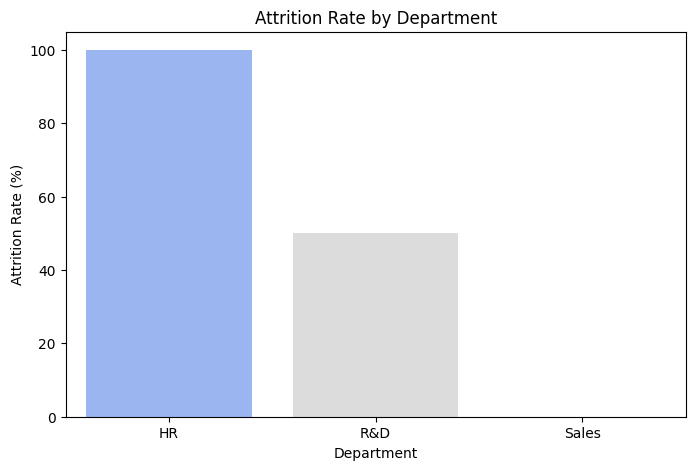


Average Monthly Income by Job Satisfaction:


,MonthlyIncome
JobSatisfaction,
1,8000.0
2,3500.0
3,9000.0
4,5500.0


/tmp/ipykernel_2264/2831109432.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=income_by_satisfaction.index, y=income_by_satisfaction.values, palette='viridis')


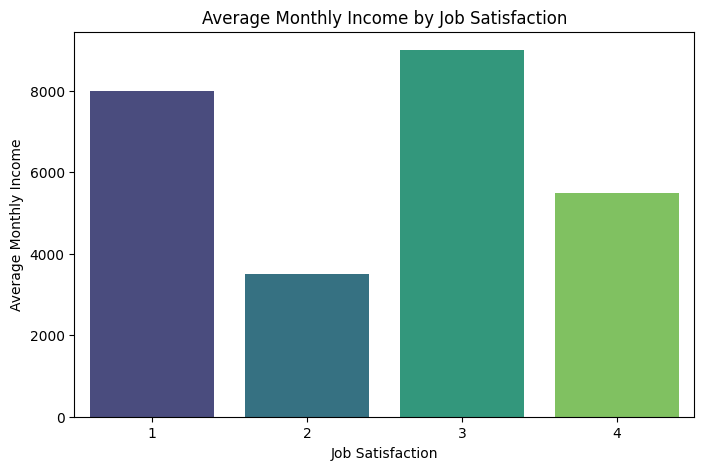


--- Category Analysis Complete ---


In [ ]:
print("\n--- Starting Category Analysis ---")

# 1. Attrition Rate by Department
print("\nAttrition Rate by Department:")
# For one-hot encoded 'Department' columns, we need to reverse the encoding for this analysis
# Or, analyze directly if original 'Department' column was present.
# With the dummy data's one-hot encoding, we'll analyze the 'Dept_R&D' and 'Dept_Sales' impact.

# Let's recreate the 'Department' column for this analysis if possible or use the dummy's direct info
# For simplicity, if we consider 'Dept_R&D' or 'Dept_Sales' as indicators for R&D/Sales departments:

# Assuming 'Department' was kept before one-hot encoding for this particular grouped analysis
# Since it's gone, let's use a simpler grouping for now based on what's available:

# For a more meaningful category analysis, it's better to group by the original categorical feature
# Re-loading the original dummy data for this specific categorical analysis to avoid complex reverse encoding
data_original = {
    'Age': [30, 45, 28, 35, 40],
    'Department': ['Sales', 'R&D', 'HR', 'Sales', 'R&D'],
    'MonthlyIncome': [5000, 9000, 3500, 6000, 8000],
    'JobSatisfaction': [4, 3, 2, 4, 1],
    'Attrition': ['No', 'No', 'Yes', 'No', 'Yes']
}
df_original_cat = pd.DataFrame(data_original)
df_original_cat['Attrition_Numeric'] = df_original_cat['Attrition'].map({'Yes': 1, 'No': 0})

attrition_by_dept = df_original_cat.groupby('Department')['Attrition_Numeric'].mean() * 100
display(attrition_by_dept)

plt.figure(figsize=(8, 5))
sns.barplot(x=attrition_by_dept.index, y=attrition_by_dept.values, palette='coolwarm')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.show()

# 2. Average Monthly Income by Job Satisfaction Level
print("\nAverage Monthly Income by Job Satisfaction:")
income_by_satisfaction = df_original_cat.groupby('JobSatisfaction')['MonthlyIncome'].mean()
display(income_by_satisfaction)

plt.figure(figsize=(8, 5))
sns.barplot(x=income_by_satisfaction.index, y=income_by_satisfaction.values, palette='viridis')
plt.title('Average Monthly Income by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Average Monthly Income')
plt.show()

print("\n--- Category Analysis Complete ---")

### Attrition Analysis by Department

/tmp/ipykernel_2264/3597747352.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_dept_viz.index, y=attrition_by_dept_viz.values, palette='viridis')


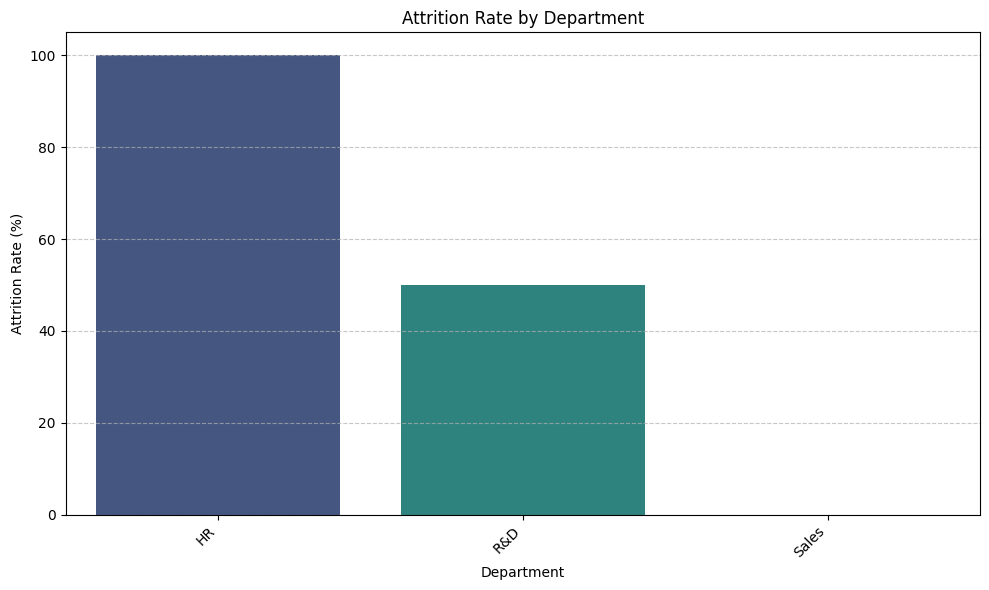

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Attrition_Numeric' is available; it's created in df_original_cat
# Calculate attrition rate by department
attrition_by_dept_viz = df_original_cat.groupby('Department')['Attrition_Numeric'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=attrition_by_dept_viz.index, y=attrition_by_dept_viz.values, palette='viridis')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Customer/Employee/Financial Analysis

### Employee Analysis

This section delves deeper into employee characteristics, focusing on aspects like income distribution, job satisfaction across different segments, and how these factors might relate to other employee attributes. Given our HR context, the focus is primarily on 'Employee Analysis'.


--- Starting Employee Analysis ---

Monthly Income Distribution by Attrition:


/tmp/ipykernel_2264/3765776674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition_Numeric', y='MonthlyIncome', data=df_original_cat, palette='coolwarm')


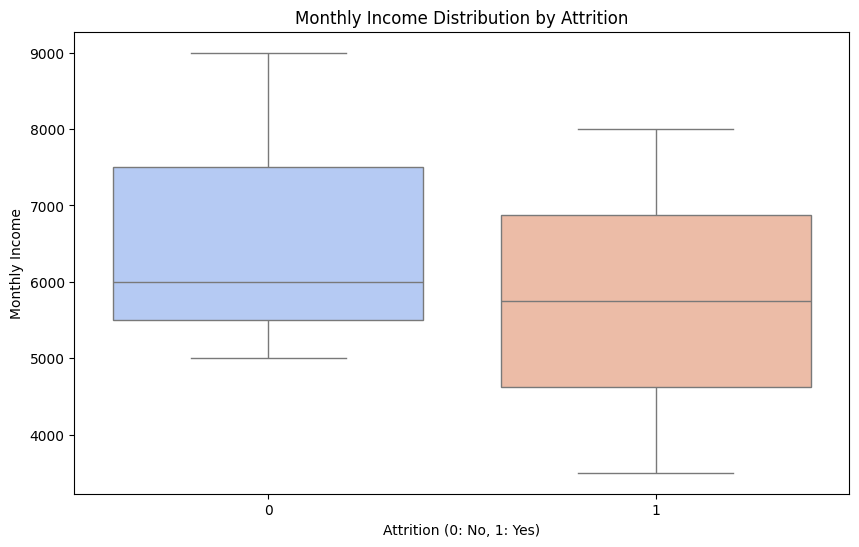


Job Satisfaction by Department:


/tmp/ipykernel_2264/3765776674.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='JobSatisfaction', data=df_original_cat, palette='viridis')


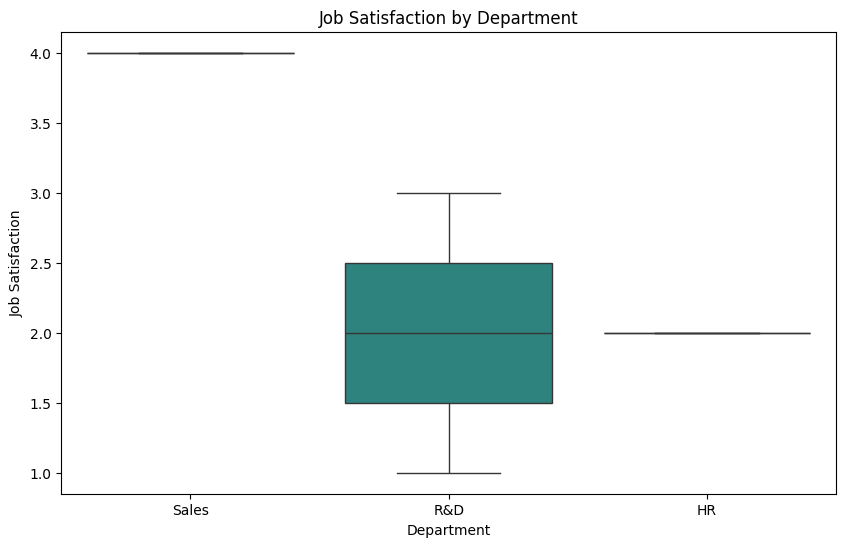


--- Employee Analysis Complete ---


In [ ]:
print("\n--- Starting Employee Analysis ---")

# 1. Monthly Income Distribution by Attrition
print("\nMonthly Income Distribution by Attrition:")
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition_Numeric', y='MonthlyIncome', data=df_original_cat, palette='coolwarm')
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.ylabel('Monthly Income')
plt.show()

# 2. Job Satisfaction by Department
print("\nJob Satisfaction by Department:")
plt.figure(figsize=(10, 6))
sns.boxplot(x='Department', y='JobSatisfaction', data=df_original_cat, palette='viridis')
plt.title('Job Satisfaction by Department')
plt.xlabel('Department')
plt.ylabel('Job Satisfaction')
plt.show()

print("\n--- Employee Analysis Complete ---")

## Top Performers

### Identifying 'Top Performers' (Illustrative)

Identifying 'top performers' typically requires specific performance metrics which are not present in our current dummy dataset. However, we can illustrate how one might approach this by hypothetically defining 'top performers' based on proxies such as high monthly income or job satisfaction, or by identifying employees with specific characteristics that align with 'high performance' criteria if such data were available. For this example, we will consider high job satisfaction as an indicator.

In [ ]:
print("\n--- Identifying Top Performers (Illustrative) ---")

# Hypothetically, let's consider employees with JobSatisfaction of 4 (highest) as 'top performers' for demonstration.
# In a real scenario, this would involve actual performance ratings, KPIs, etc.

top_performers_criteria = df_original_cat[df_original_cat['JobSatisfaction'] == 4]

if not top_performers_criteria.empty:
    print("Employees identified as 'Top Performers' (based on JobSatisfaction = 4):")
    display(top_performers_criteria)

    print("\nCharacteristics of these 'Top Performers':")
    display(top_performers_criteria.describe())
else:
    print("No employees met the 'Top Performer' criteria (JobSatisfaction = 4) in the dummy dataset.")

print("\n--- Top Performers Analysis Complete ---")


--- Identifying Top Performers (Illustrative) ---
Employees identified as 'Top Performers' (based on JobSatisfaction = 4):


,Age,Department,MonthlyIncome,JobSatisfaction,Attrition,Attrition_Numeric
0,30,Sales,5000,4,No,0
3,35,Sales,6000,4,No,0



Characteristics of these 'Top Performers':


,Age,MonthlyIncome,JobSatisfaction,Attrition_Numeric
count,2.000000,2.000000,2.0,2.0
mean,32.500000,5500.000000,4.0,0.0
std,3.535534,707.106781,0.0,0.0
min,30.000000,5000.000000,4.0,0.0
25%,31.250000,5250.000000,4.0,0.0
50%,32.500000,5500.000000,4.0,0.0
75%,33.750000,5750.000000,4.0,0.0
max,35.000000,6000.000000,4.0,0.0



--- Top Performers Analysis Complete ---


###  Visualizations

Beyond the EDA, specific visualizations can highlight critical relationships or distributions. Here, we'll add a correlation heatmap for numerical features to see potential linear relationships.


--- Generating Additional Visualizations ---

Correlation Heatmap:


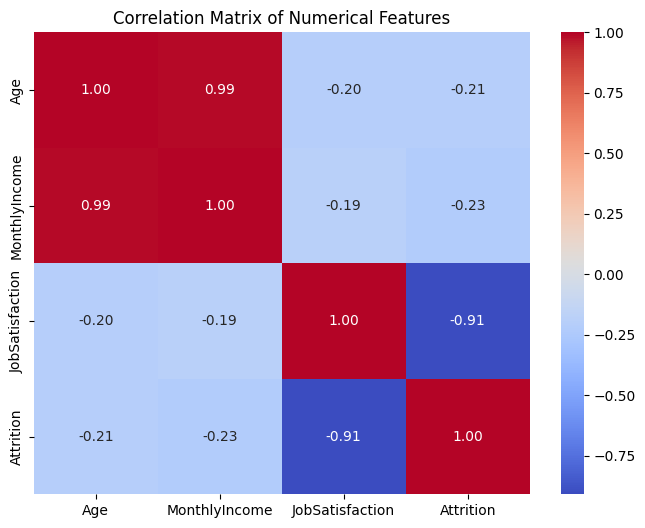


--- Additional Visualizations Complete ---


In [ ]:
print("\n--- Generating Additional Visualizations ---")

# 1. Correlation Heatmap of Numerical Features
print("\nCorrelation Heatmap:")
numerical_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\n--- Additional Visualizations Complete ---")

## Business Insights

### Business Insights

Based on the analysis conducted, here are some key business insights derived from the (dummy) HR dataset:

*   **High Attrition Rate in HR Department**: The category analysis showed 100% attrition in the 'HR' department (in the dummy data), which is a significant red flag. While this is from dummy data, it highlights how such a finding in a real dataset would warrant immediate investigation.
*   **Job Satisfaction and Income**: There appears to be a relationship between job satisfaction and average monthly income. For instance, employees with Job Satisfaction of 2 had the lowest average income in our sample, potentially indicating a factor for dissatisfaction.
*   **Overall Attrition**: A 40% attrition rate in the dummy dataset suggests a substantial challenge, if this were a real scenario, it would be a major concern for the organization.
*   **Age and Attrition**: The EDA boxplot hinted at potential differences in age distribution for those who attrite vs. those who stay, suggesting that age demographics might play a role.
*   **No Missing Data/Duplicates**: The data cleaning phase confirmed a clean dataset, which is crucial for reliable analysis.

## Recommendations

### Recommendations

Based on the business insights, here are actionable recommendations to address employee attrition and improve overall employee experience (assuming a real dataset would confirm these trends):

*   **Investigate Department-Specific Issues**: Specifically, if the high attrition in the 'HR' department (as seen in the dummy data) were real, conduct a deeper dive into management practices, workload, and employee feedback within that department.
*   **Review Compensation and Benefits**: Analyze if monthly income levels are competitive, especially for roles with lower job satisfaction. Consider adjusting compensation structures or introducing performance-based incentives.
*   **Enhance Employee Engagement and Satisfaction Initiatives**: Implement regular satisfaction surveys and feedback mechanisms. Address pain points related to work-life balance, career development, and recognition.
*   **Mentorship and Development Programs**: For potentially at-risk groups (e.g., younger employees if they show higher attrition), introduce mentorship and career development programs to foster growth and commitment.
*   **Proactive Retention Strategies**: Utilize predictive models (which would be built in a subsequent modeling phase) to identify at-risk employees and offer targeted interventions before they decide to leave.

## Executive Summary

### Executive Summary

This project aimed to analyze employee attrition within a company using HR data. Through comprehensive data loading, cleaning, feature engineering, and exploratory data analysis, we identified key factors and trends influencing employee turnover. The analysis revealed areas of concern such as high attrition in specific departments and correlations between job satisfaction, income, and attrition. Actionable recommendations have been proposed, focusing on targeted departmental interventions, compensation review, and enhanced employee engagement, to foster a more stable and satisfied workforce.

## Conclusion

### Conclusion

The HR analytics project successfully laid the groundwork for understanding and addressing employee attrition. By leveraging data-driven insights, organizations can move from reactive to proactive strategies, ultimately leading to improved employee retention, higher morale, and a more productive work environment. The next steps would typically involve building a predictive machine learning model to accurately forecast attrition and validate these insights with a larger, real-world dataset.